# Step 7: Fire-susceptibility models (v2 evaluation protocol)

**Protocol of record:** the 2026-09-24/25 end-to-end audit, `results/FULL_METHODOLOGY_AUDIT.md` (project root), summarised
for this repository in `AUDIT_2026-09-25.md`. Paper numbers come **only** from `results/FINAL_MANUSCRIPT_NUMBERS.md`.
This notebook replaces the v1 notebook, which used an 80/20 split, pre-split imputation, a random 5-fold CV, a GroupKFold
"spatial CV" that did not match CDR-PINO's folds, and a half-pixel-shifted label.

**Input:** Step 6's v2 `Integrated_Outputs/Integrated_FireRisk_Pixels.parquet`. Rows are India-mask pixels with a finite NDVI
mean, in row-major `grid_index` order. Columns are `lon, lat, grid_index, fire_count, fire_ever` plus **55 features**:
- NDVI level, June climatology, Seasonal-Kendall τ, Sen slope, CVSI and LISA.
- Seven FLDAS climatological levels and their Seasonal-Kendall τ.
- LST day, night and DTR levels and their τ.
- Elevation, slope, and aspect as sin/cos.
- Distances to roads, railways and waterways.
- 21 land-cover fractions from 2001, plus `forest_frac_baseline`.

**v2 protocol, implemented in `step7_models.py` and `preprocessing.py`:**

| Item | Definition |
|---|---|
| Split (Track A) | Two-stage stratified random split on row position (`random_state=42`): 20% test, then 15/80 of the remainder as validation, giving **65/15/20**. This is identical to the audit's `v2_split`, and the construction was verified exactly. |
| Imputation | Median fitted on **training rows only**. |
| Populations | **Forest pixels (`forest_frac_baseline > 0`) are PRIMARY**, because forest fraction alone gives AUC ≈ 0.91 over all pixels. All pixels are always reported too, each with its prevalence. |
| RF | `n_estimators=200, max_depth=25, min_samples_leaf=3, class_weight='balanced', max_features='sqrt', random_state=42`. Scores are class-balanced and **not calibrated probabilities**. |
| MaxEnt (v2) | `elapid`, linear + hinge + product, β = 4.0, 150k stratified training subsample (`random_state=42`). |
| Biswas-15 | The 15 level predictors of Biswas et al. (2025) Table 3 (aspect in degrees, rebuilt from sin/cos). Fitted with RF, and with MaxEnt (L+Q+H+P, β = 1). |
| CDR-PINO covariates | RF on CDR-PINO's 5 static covariates (tag `RF_cdr7static`, kept for 1:1 comparison with the audit tables). |
| Ablations | RF v2 without the land-cover, trend, or terrain groups. |
| Track B1 | 3 folds of 2° blocks, with fold geometry identical to CDR-PINO (`partitions.npz`) and block-carved validation (seed 42+1000, fraction 0.1875). |
| Track B2 | Leave one region out, over CDR-PINO's 6 KMeans regions (nearest centroid). |
| Track B3 (static) | Fit the label "burned in non-test years", score "burned in held-out years" 2000/2008/2009/2015 on the same pixels, with a persistence null. |
| Metrics | ROC-AUC, AP, prevalence, Brier, ECE, and precision / recall / specificity / F1 at the **max-F1 threshold chosen on validation** (none where there is no validation split). Also stratified bootstrap CIs, paired DeLong on identical test pixels (Track A), and block bootstrap over 2° blocks (B1/B2 pooled folds). |
| Diagnostics | Permutation importance at feature and group level, plus partial dependence, for RF v2, MaxEnt v2, RF Biswas-15 and MaxEnt Biswas-15. |
| Bridge | 12 km, CDR-PINO population and partitions (RF / LogReg / MaxEnt on CDR covariates and on v2 features aggregated to 12 km). |
| Biswas-style | 0.25°, 2020 presences, 10 splits. This is a **reimplementation, not the original Biswas et al. result**, and its presence-vs-background AUC is not comparable with the pixel-level AUCs. |
| Map | RF v2 relative-score GeoTIFF plus a 5-class map with quantile breaks computed over **forest** pixels, carrying provenance tags. |

## Run mode and expected result files

`RUN_MODELS = False` (default) **fits nothing**: every table and figure below is built from result files already in
`Model_Outputs/`. The files are located **by exact file name, recursively**, so the flat layout of copied audit files and
the sub-folder layout written by `step7_models.py` both work. `RUN_MODELS = True` runs `step7_models.py` for the stages in
`RUN_STAGES`. The full refit takes about 16 h of CPU time.

| File name (exact) | Content | Written by (refit) / audit source |
|---|---|---|
| `CLASSICAL_METRICS.csv` | One row per experiment × tag × population (× fold/region) | `analyze` → `metrics/` · `results/baseline/` |
| `PAIRED_trackA.csv` | Paired DeLong, Track A | `analyze` · `results/baseline/` |
| `PAIRED_B1_B2.csv` | Pooled-fold block bootstrap, B1/B2 | `analyze` · `results/baseline/` |
| `B1_B2_SUMMARY.csv` | Mean/sd over folds | `analyze` · `results/baseline/` |
| `FINAL_METRICS.csv` (audit) / `STEP7_METRICS_BY_TRACK.csv` (refit) | Per-track means | `results/final/` · `analyze` |
| `importance__trackA__{RF_v2,MaxEnt_v2,RF_biswas15,MaxEnt_biswas15_LQHP}.json` | Permutation importance (feature, group), PDP | `trackA` → `importance/` · `results/baseline/` |
| `trackA__{tag}.npz` | Test predictions `y, p, pop_all, pop_forest` | `trackA` → `predictions/` |
| `B1__{tag}__f{k}.npz`, `B2__{tag}__r{k}.npz` | Same, plus `blocks` | `B1` / `B2` → `predictions/` |
| `B3static__{tag}.npz`, `maxent_n__{tag}.npz` | Same | `B3` / `maxent_n` → `predictions/` |
| `bridge12_{A,B1,B2,B3}__{tag}.npz` (tags carry `_f{k}` / `_r{k}`) | 12 km bridge predictions | `bridge` → `bridge_predictions/` · `results/baseline/predictions/` |
| `BISWAS_STYLE_BASELINE.json` | Biswas-style reimplementation | `biswas` → `biswas_reference/` · `results/biswas_reference/` |
| `Susceptibility_RF_v2_score.tif`, `Susceptibility_RF_v2_5class_quantile.tif` | Final maps with provenance tags | `map` → `maps/` · `results/final/maps/` |

Tags: `RF_v2, MaxEnt_v2, RF_biswas15, MaxEnt_biswas15_LQHP, RF_cdr7static, RF_v2_minus_{landcover,trends,terrain}`. The audit
files also contain extra tags (v1-feature and label-variant runs, resolution sensitivities); these are shown where present.
Files in `Model_Outputs/` from the v1 notebook (`Fire_Susceptibility_Probability.tif`, `ROC_PR_Curves.png`, ...) are
**historical and superseded**. They are never read here.

In [1]:
# ============================ CONFIGURATION ============================
RUN_MODELS = False          # False: load precomputed results only (no fitting). True: refit via step7_models.py
RUN_STAGES = ["trackA", "B1", "B2", "B3", "maxent_n", "bridge", "biswas", "map", "analyze"]   # used only if RUN_MODELS
INSTALL_DEPS = False        # True: pip-install the dependency list below into this kernel first
# =======================================================================
import os, sys, json, re, time, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP7_DIR = Path(r"D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis")
OUTPUT_DIR = Path(os.environ.get("STEP7_OUTPUT_DIR", STEP7_DIR / "Model_Outputs"))
FIG_DIR = OUTPUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
PARQUET = STEP7_DIR / "Integrated_Outputs" / "Integrated_FireRisk_Pixels.parquet"
PRIMARY = ["RF_v2", "MaxEnt_v2", "RF_biswas15", "MaxEnt_biswas15_LQHP", "RF_cdr7static",
           "RF_v2_minus_landcover", "RF_v2_minus_trends", "RF_v2_minus_terrain"]
IMPORTANCE_MODELS = ["RF_v2", "MaxEnt_v2", "RF_biswas15", "MaxEnt_biswas15_LQHP"]
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 200)
print("Output directory:", OUTPUT_DIR, "| RUN_MODELS =", RUN_MODELS)

Output directory: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs | RUN_MODELS = False


In [2]:
if INSTALL_DEPS:
    for pkg in ["numpy", "pandas", "matplotlib", "scipy", "scikit-learn>=1.9", "pyarrow", "rasterio", "elapid>=1.0.4"]:
        subprocess.call([sys.executable, "-m", "pip", "install", pkg, "-q"])
if RUN_MODELS:
    # Full refit: ~16 h CPU in total (MaxEnt fits dominate). Each stage appends to metrics/experiment_registry.jsonl.
    for stage in RUN_STAGES:
        t0 = time.time()
        print(f"=== step7_models.py {stage} ===", flush=True)
        proc = subprocess.Popen([sys.executable, str(STEP7_DIR / "step7_models.py"), stage, "--out", str(OUTPUT_DIR)],
                                cwd=str(STEP7_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in proc.stdout:
            print(line, end="")
        if proc.wait() != 0:
            raise RuntimeError(f"stage {stage} failed (exit {proc.returncode})")
        print(f"=== {stage}: {time.time() - t0:.0f}s ===", flush=True)
else:
    print("RUN_MODELS=False: nothing is fitted; loading precomputed results from", OUTPUT_DIR)

RUN_MODELS=False: nothing is fitted; loading precomputed results from D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs


## Result-file inventory

`find()` resolves an exact file name anywhere under `OUTPUT_DIR`. If a name exists more than once, the shallowest path wins.

In [3]:
def _index(root):
    idx = {}
    for p in sorted(Path(root).rglob("*"), key=lambda q: (len(q.parts), str(q))):
        if p.is_file():
            idx.setdefault(p.name, p)
    return idx
FILES = _index(OUTPUT_DIR)

def find(name):
    return FILES.get(name)

def read_csv(name):
    p = find(name)
    return pd.read_csv(p) if p is not None else None

def load_npz(name):
    p = find(name)
    return np.load(p) if p is not None else None

def show(df, cols=None, n=None):
    if df is None or len(df) == 0:
        print("  (no rows)"); return
    d = df[[c for c in (cols or df.columns) if c in df.columns]]
    display(d if n is None else d.head(n))

expected = ["CLASSICAL_METRICS.csv", "PAIRED_trackA.csv", "PAIRED_B1_B2.csv", "B1_B2_SUMMARY.csv",
            "BISWAS_STYLE_BASELINE.json", "Susceptibility_RF_v2_score.tif", "Susceptibility_RF_v2_5class_quantile.tif"]
expected += [f"importance__trackA__{m}.json" for m in IMPORTANCE_MODELS]
expected += [f"trackA__{m}.npz" for m in PRIMARY]
expected += [f"B1__{m}__f{k}.npz" for m in ["RF_v2", "RF_biswas15", "RF_cdr7static", "MaxEnt_v2", "MaxEnt_biswas15_LQHP"] for k in range(3)]
expected += [f"B2__{m}__r{k}.npz" for m in ["RF_v2", "RF_biswas15", "RF_cdr7static", "MaxEnt_v2", "MaxEnt_biswas15_LQHP"] for k in range(6)]
expected += [f"B3static__{m}.npz" for m in ["RF_v2", "RF_biswas15", "MaxEnt_v2", "persistence_null_everburned_trainyears"]]
inv = pd.DataFrame([dict(file=f, present=find(f) is not None,
                         location=str(find(f).parent.relative_to(OUTPUT_DIR)) if find(f) is not None else "") for f in expected])
print(f"{inv.present.sum()}/{len(inv)} expected files present;",
      f"{sum(1 for k in FILES if k.startswith('bridge12_'))} bridge12 prediction files;",
      f"{sum(1 for k in FILES if k.startswith('maxent_n__'))} maxent_n prediction files")
show(inv[~inv.present]) if (~inv.present).any() else print("All expected files found.")
M = read_csv("CLASSICAL_METRICS.csv")
if M is None:
    raise FileNotFoundError("CLASSICAL_METRICS.csv not found under OUTPUT_DIR -- populate Model_Outputs/ or set RUN_MODELS=True")
for c in ("auc_ci95", "ap_ci95"):
    M[c] = M[c].apply(lambda s: json.loads(s) if isinstance(s, str) and s.startswith("[") else None)
M["auc_ci"] = M.auc_ci95.apply(lambda v: f"[{v[0]:.4f}, {v[1]:.4f}]" if v else "")
M["ap_ci"] = M.ap_ci95.apply(lambda v: f"[{v[0]:.4f}, {v[1]:.4f}]" if v else "")
print("CLASSICAL_METRICS:", len(M), "rows; experiments:", sorted(M.experiment.unique()))

68/68 expected files present; 64 bridge12 prediction files; 11 maxent_n prediction files
All expected files found.
CLASSICAL_METRICS: 301 rows; experiments: ['B1', 'B1hist', 'B1hist_v2origin', 'B2', 'B3static', 'bridge12_A', 'bridge12_B1', 'bridge12_B2', 'bridge12_B3', 'maxent_n', 'repro', 'trackA']


## Data and populations

This cell reads only the label and forest columns of the Step 6 table, if it is present, and reports prevalence per
population and split. It checks that the table is the v2 table: it must contain a `grid_index` column in row-major
order.

In [4]:
sys.path.insert(0, str(STEP7_DIR))
import preprocessing as pp
if PARQUET.exists():
    import pyarrow.parquet as pq
    names = pq.read_schema(PARQUET).names
    if "grid_index" not in names:
        print("Integrated_FireRisk_Pixels.parquet is still the v1 table (no grid_index): population summary skipped.")
    else:
        dfl = pd.read_parquet(PARQUET, columns=["grid_index", pp.TARGET_COL, pp.FOREST_COL])
        y, fm = pp.label_of(dfl), pp.forest_mask(dfl)
        split = pp.v2_split(y)
        print(f"{len(dfl):,} pixels, {len(pp.feature_columns(pd.DataFrame(columns=names)))} features; "
              f"row-major: {bool((np.diff(dfl.grid_index.values) > 0).all())}")
        rows = []
        for part, nm in pp.SPLIT_NAMES.items():
            for pop, msk in (("all", np.ones(len(y), bool)), ("forest", fm)):
                s = (split == part) & msk
                rows.append(dict(split=nm, population=pop, n=int(s.sum()), n_fire=int(y[s].sum()), prevalence=float(y[s].mean())))
        show(pd.DataFrame(rows))
else:
    print("Step 6 parquet not found; population figures below come from the metric files.")

4,160,768 pixels, 55 features; row-major: True


,split,population,n,n_fire,prevalence
0,train,all,2704498,174467,0.064510
1,train,forest,779184,173783,0.223032
2,val,all,624116,40262,0.064510
3,val,forest,179495,40077,0.223276
4,test,all,832154,53682,0.064510
5,test,forest,238859,53481,0.223902


## Track A: random 65/15/20 split, both populations

The threshold metrics use the max-F1 threshold chosen on the **validation** partition. The CIs come from a stratified
bootstrap (100 resamples).

In [5]:
cols = ["tag", "population", "n", "prevalence", "roc_auc", "auc_ci", "ap", "ap_ci", "brier", "ece",
        "thr_valmaxF1", "precision", "recall_sensitivity", "specificity", "f1", "train_rows", "fit_sec"]
A = M[M.experiment == "trackA"].copy()
A["_o"] = A.tag.map({t: i for i, t in enumerate(PRIMARY)}).fillna(99)
A = A.sort_values(["population", "_o", "tag"], key=lambda s: s.map({"forest": 0, "all": 1}) if s.name == "population" else s)
print("PRIMARY population = forest pixels. Primary model set:")
show(A[A.tag.isin(PRIMARY)], cols)
if (~A.tag.isin(PRIMARY)).any():
    print("Additional audit runs (v1 features / label variants / resolution sensitivities):")
    show(A[~A.tag.isin(PRIMARY)], cols)

PRIMARY population = forest pixels. Primary model set:


,tag,population,n,prevalence,roc_auc,auc_ci,ap,ap_ci,brier,ece,thr_valmaxF1,precision,recall_sensitivity,specificity,f1,train_rows,fit_sec
3,RF_v2,forest,238859,0.223902,0.897077,"[0.8957, 0.8983]",0.721245,"[0.7181, 0.7242]",0.177451,0.219293,0.799880,0.614646,0.725678,0.868744,0.665563,2704498.0,162.501649
27,MaxEnt_v2,forest,238859,0.223902,0.865742,"[0.8639, 0.8672]",0.664287,"[0.6605, 0.6688]",0.123593,0.053753,0.403817,0.565655,0.686992,0.847814,0.620447,150000.0,1680.934226
11,RF_biswas15,forest,238859,0.223902,0.884762,"[0.8833, 0.8860]",0.698031,"[0.6948, 0.7013]",0.176757,0.208878,0.792622,0.610123,0.696210,0.871651,0.650330,2704498.0,103.039450
29,MaxEnt_biswas15_LQHP,forest,238859,0.223902,0.817791,"[0.8160, 0.8195]",0.576799,"[0.5735, 0.5811]",0.165452,0.132820,0.519673,0.493374,0.662740,0.803666,0.565651,150000.0,1315.023381
13,RF_cdr7static,forest,238859,0.223902,0.826102,"[0.8243, 0.8277]",0.547879,"[0.5446, 0.5518]",0.244209,0.283916,0.774902,0.468713,0.721452,0.764077,0.568247,2704498.0,82.388076
15,RF_v2_minus_landcover,forest,238859,0.223902,0.889326,"[0.8880, 0.8906]",0.704224,"[0.7005, 0.7079]",0.173144,0.203827,0.754549,0.584730,0.748677,0.846605,0.656625,2704498.0,149.159602
17,RF_v2_minus_trends,forest,238859,0.223902,0.891462,"[0.8901, 0.8929]",0.708568,"[0.7054, 0.7118]",0.186134,0.230425,0.797105,0.595403,0.728464,0.857189,0.655247,2704498.0,131.532177
19,RF_v2_minus_terrain,forest,238859,0.223902,0.897686,"[0.8963, 0.8989]",0.723584,"[0.7205, 0.7262]",0.176183,0.217706,0.807598,0.625802,0.713375,0.876938,0.666725,2704498.0,151.379464
2,RF_v2,all,832154,0.064510,0.974974,"[0.9746, 0.9752]",0.720032,"[0.7166, 0.7231]",0.051163,0.063979,0.799880,0.614760,0.723427,0.968739,0.664681,2704498.0,162.501649
26,MaxEnt_v2,all,832154,0.064510,0.967018,"[0.9666, 0.9674]",0.662550,"[0.6602, 0.6666]",0.035717,0.015338,0.403817,0.565493,0.684550,0.963729,0.619352,150000.0,1680.934226


Additional audit runs (v1 features / label variants / resolution sensitivities):


,tag,population,n,prevalence,roc_auc,auc_ci,ap,ap_ci,brier,ece,thr_valmaxF1,precision,recall_sensitivity,specificity,f1,train_rows,fit_sec
31,MaxEnt_v1_corrlabel,forest,238859,0.223902,0.865784,"[0.8641, 0.8675]",0.662117,"[0.6580, 0.6655]",0.124059,0.055931,0.397920,0.559183,0.696958,0.841491,0.620515,150000.0,1875.683506
5,RF_v1_corrlabel,forest,238859,0.223902,0.898124,"[0.8969, 0.8994]",0.724803,"[0.7217, 0.7276]",0.173453,0.215475,0.796841,0.624986,0.716067,0.876042,0.667434,2704498.0,155.324605
7,RF_v1_corrlabel_minus_labelderived,forest,238859,0.223902,0.898354,"[0.8971, 0.8996]",0.725432,"[0.7224, 0.7280]",0.173676,0.215986,0.786581,0.617195,0.728988,0.869558,0.668450,2704498.0,155.299631
9,RF_v1_histlabel,forest,238859,0.221063,0.886719,"[0.8852, 0.8885]",0.701589,"[0.6974, 0.7056]",0.179975,0.225896,0.792456,0.614805,0.695377,0.876354,0.652614,2704498.0,162.980035
21,RF_v2_label_conf30,forest,238859,0.218162,0.896603,"[0.8953, 0.8978]",0.714328,"[0.7110, 0.7174]",0.177298,0.220216,0.799856,0.610911,0.720303,0.871989,0.661113,2704498.0,157.201495
25,RF_v2_label_conf30_type0,forest,238859,0.218041,0.896528,"[0.8952, 0.8977]",0.714018,"[0.7109, 0.7179]",0.178383,0.221595,0.792380,0.600713,0.731418,0.864438,0.659653,2704498.0,156.303107
23,RF_v2_label_type0,forest,238859,0.223776,0.897314,"[0.8958, 0.8987]",0.721664,"[0.7180, 0.7249]",0.177405,0.219444,0.800510,0.615976,0.724926,0.869709,0.666025,2704498.0,159.378223
33,RF_v2_lst005,forest,238859,0.223902,0.897289,"[0.8958, 0.8986]",0.722286,"[0.7193, 0.7249]",0.177508,0.220064,0.769467,0.590818,0.757465,0.848655,0.663843,2704498.0,143.991749
37,RF_v2_slope025,forest,238859,0.223902,0.897557,"[0.8962, 0.8987]",0.722151,"[0.7191, 0.7247]",0.176990,0.218846,0.791344,0.608208,0.736579,0.863112,0.666266,2704498.0,142.140755
35,RF_v2_slopezt,forest,238859,0.223902,0.897105,"[0.8957, 0.8983]",0.721957,"[0.7189, 0.7249]",0.177630,0.219648,0.796499,0.611420,0.729792,0.866192,0.665382,2704498.0,146.297117


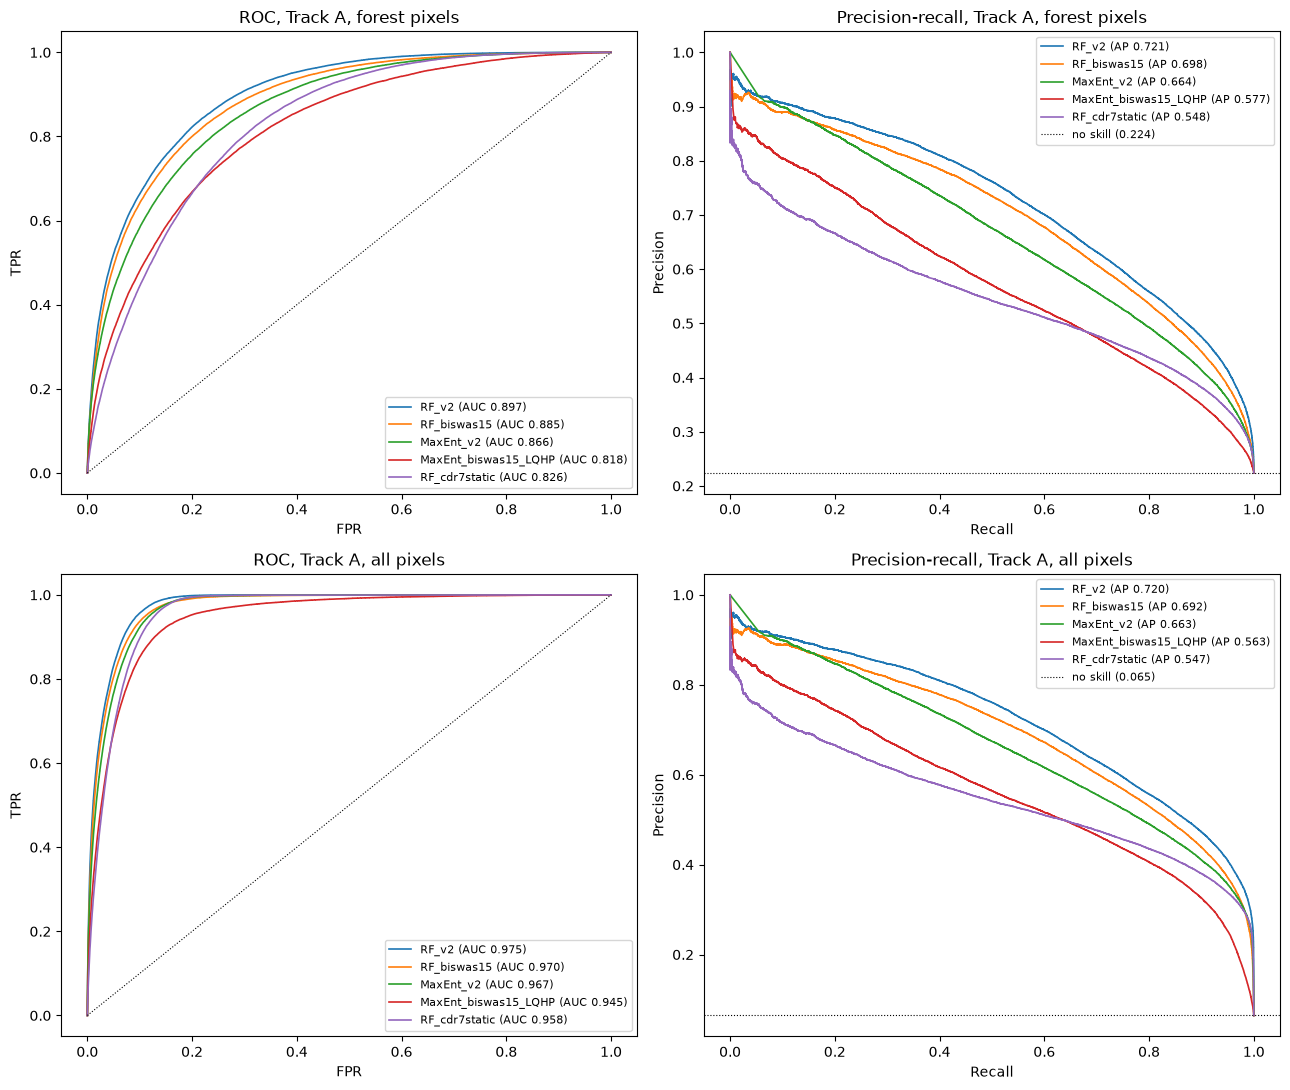

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve
curve_models = [t for t in ["RF_v2", "RF_biswas15", "MaxEnt_v2", "MaxEnt_biswas15_LQHP", "RF_cdr7static"] if find(f"trackA__{t}.npz")]
if curve_models:
    fig, ax = plt.subplots(2, 2, figsize=(13, 11))
    for i, pop in enumerate(("forest", "all")):
        for t in curve_models:
            z = load_npz(f"trackA__{t}.npz"); m = z[f"pop_{pop}"]; yy, p = z["y"][m], z["p"][m]
            r = A[(A.tag == t) & (A.population == pop)]
            fpr, tpr, _ = roc_curve(yy, p); pr, rc, _ = precision_recall_curve(yy, p)
            ax[i, 0].plot(fpr, tpr, lw=1.2, label=f"{t} (AUC {r.roc_auc.iloc[0]:.3f})")
            ax[i, 1].plot(rc, pr, lw=1.2, label=f"{t} (AP {r.ap.iloc[0]:.3f})")
        ax[i, 0].plot([0, 1], [0, 1], "k:", lw=.8); ax[i, 1].axhline(yy.mean(), color="k", ls=":", lw=.8, label=f"no skill ({yy.mean():.3f})")
        ax[i, 0].set(title=f"ROC, Track A, {pop} pixels", xlabel="FPR", ylabel="TPR")
        ax[i, 1].set(title=f"Precision-recall, Track A, {pop} pixels", xlabel="Recall", ylabel="Precision")
        ax[i, 0].legend(fontsize=8); ax[i, 1].legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG_DIR / "nb_TrackA_ROC_PR.png", dpi=150); plt.show()
else:
    print("No Track-A prediction files found.")

### Calibration

`class_weight='balanced'` shifts RF scores upwards, so an RF score is a **relative susceptibility score, not a
probability**. The reliability diagrams and the ECE (10 bins) below quantify this.

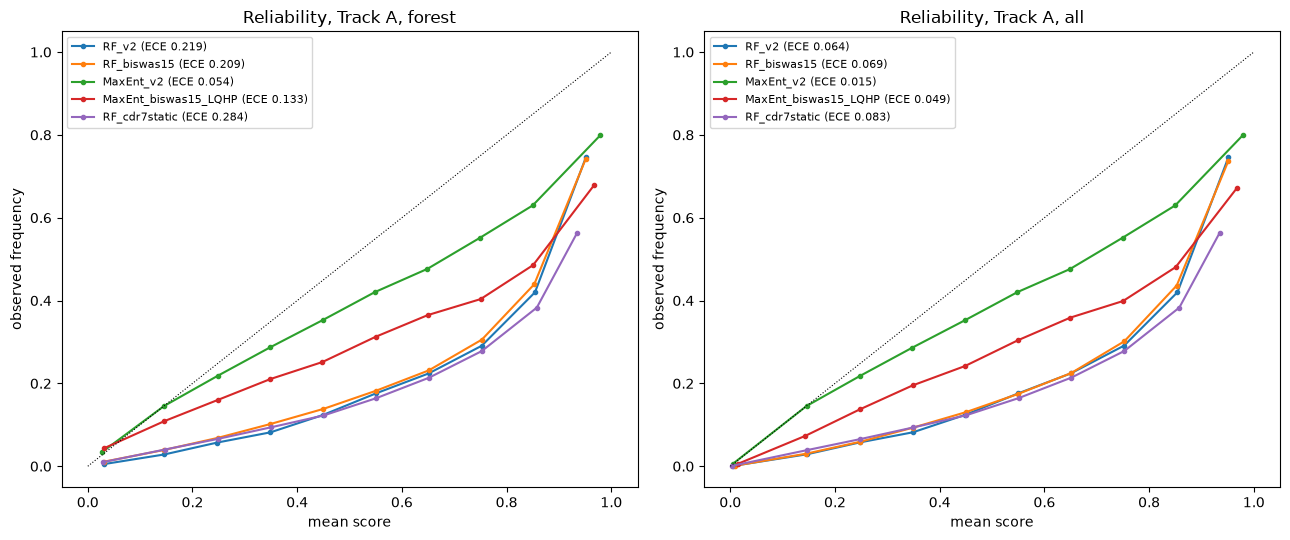

In [7]:
if curve_models:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    for i, pop in enumerate(("forest", "all")):
        for t in curve_models:
            z = load_npz(f"trackA__{t}.npz"); m = z[f"pop_{pop}"]; yy, p = z["y"][m].astype(float), z["p"][m].astype(float)
            b = np.clip(np.digitize(p, np.linspace(0, 1, 11)) - 1, 0, 9)
            xs = [p[b == k].mean() for k in range(10) if (b == k).any()]; ys = [yy[b == k].mean() for k in range(10) if (b == k).any()]
            e = A[(A.tag == t) & (A.population == pop)].ece.iloc[0]
            ax[i].plot(xs, ys, "o-", ms=3, label=f"{t} (ECE {e:.3f})")
        ax[i].plot([0, 1], [0, 1], "k:", lw=.8); ax[i].set(title=f"Reliability, Track A, {pop}", xlabel="mean score", ylabel="observed frequency")
        ax[i].legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG_DIR / "nb_TrackA_reliability.png", dpi=150); plt.show()

### Paired contributions: DeLong on identical Track-A test pixels

`diff` is AUC(A) − AUC(B) with a 95% CI and a p-value. Label-variant runs are not paired against the primary label.

In [8]:
PA = read_csv("PAIRED_trackA.csv")
show(PA.sort_values(["population", "question"]) if PA is not None else None,
     ["question", "model_A", "model_B", "population", "n", "prevalence", "auc_A", "auc_B", "diff", "ci95_lo", "ci95_hi", "p", "ap_A", "ap_B"])

,question,model_A,model_B,population,n,prevalence,auc_A,auc_B,diff,ci95_lo,ci95_hi,p,ap_A,ap_B
14,Biswas-15 vs CDR-PINO's 5 static covariates,RF_biswas15,RF_cdr7static,all,832154,0.064510,0.970385,0.957636,0.012749,0.012369,0.013129,0.000000e+00,0.691916,0.546705
12,CDR-PINO's 5 static covariates vs v2,RF_v2,RF_cdr7static,all,832154,0.064510,0.974974,0.957636,0.017338,0.017023,0.017652,0.000000e+00,0.720032,0.546705
22,LST at 0.05 deg (MOD11C3 resolution proxy),RF_v2,RF_v2_lst005,all,832154,0.064510,0.974974,0.975044,-0.000071,-0.000131,-0.000011,2.100224e-02,0.720032,0.721078
0,added predictors / feature engineering,RF_v2,RF_biswas15,all,832154,0.064510,0.974974,0.970385,0.004589,0.004360,0.004817,0.000000e+00,0.720032,0.691916
20,added predictors under MaxEnt,MaxEnt_v2,MaxEnt_biswas15_LQHP,all,832154,0.064510,0.967018,0.945087,0.021932,0.021317,0.022546,0.000000e+00,0.662680,0.562995
4,label-derived NDVI features,RF_v1_corrlabel,RF_v1_corrlabel_minus_labelderived,all,832154,0.064510,0.975395,0.975454,-0.000059,-0.000111,-0.000006,2.866416e-02,0.723980,0.724599
6,land-cover group,RF_v2,RF_v2_minus_landcover,all,832154,0.064510,0.974974,0.971712,0.003261,0.003062,0.003461,1.943895e-225,0.720032,0.698257
18,model family RF vs MaxEnt (Biswas-15),RF_biswas15,MaxEnt_biswas15_LQHP,all,832154,0.064510,0.970385,0.945087,0.025298,0.024730,0.025866,0.000000e+00,0.691916,0.562995
16,model family RF vs MaxEnt (v2),RF_v2,MaxEnt_v2,all,832154,0.064510,0.974974,0.967018,0.007955,0.007721,0.008190,0.000000e+00,0.720032,0.662680
24,slope algorithm Horn vs Zevenbergen-Thorne,RF_v2,RF_v2_slopezt,all,832154,0.064510,0.974974,0.974978,-0.000004,-0.000064,0.000056,8.933505e-01,0.720032,0.720728


## Permutation importance and partial dependence

The importance is the drop in test ROC-AUC on a fixed stratified 200k test subsample, averaged over 5 repeats. Group
importance permutes all of a group's columns jointly. The v2 groups are vegetation, climate levels, climate trends,
LST, terrain, human and land cover; for the Biswas-15 models each group is one Biswas variable. The audit files prefix
v2 columns with `v2_`, which is stripped here for display.

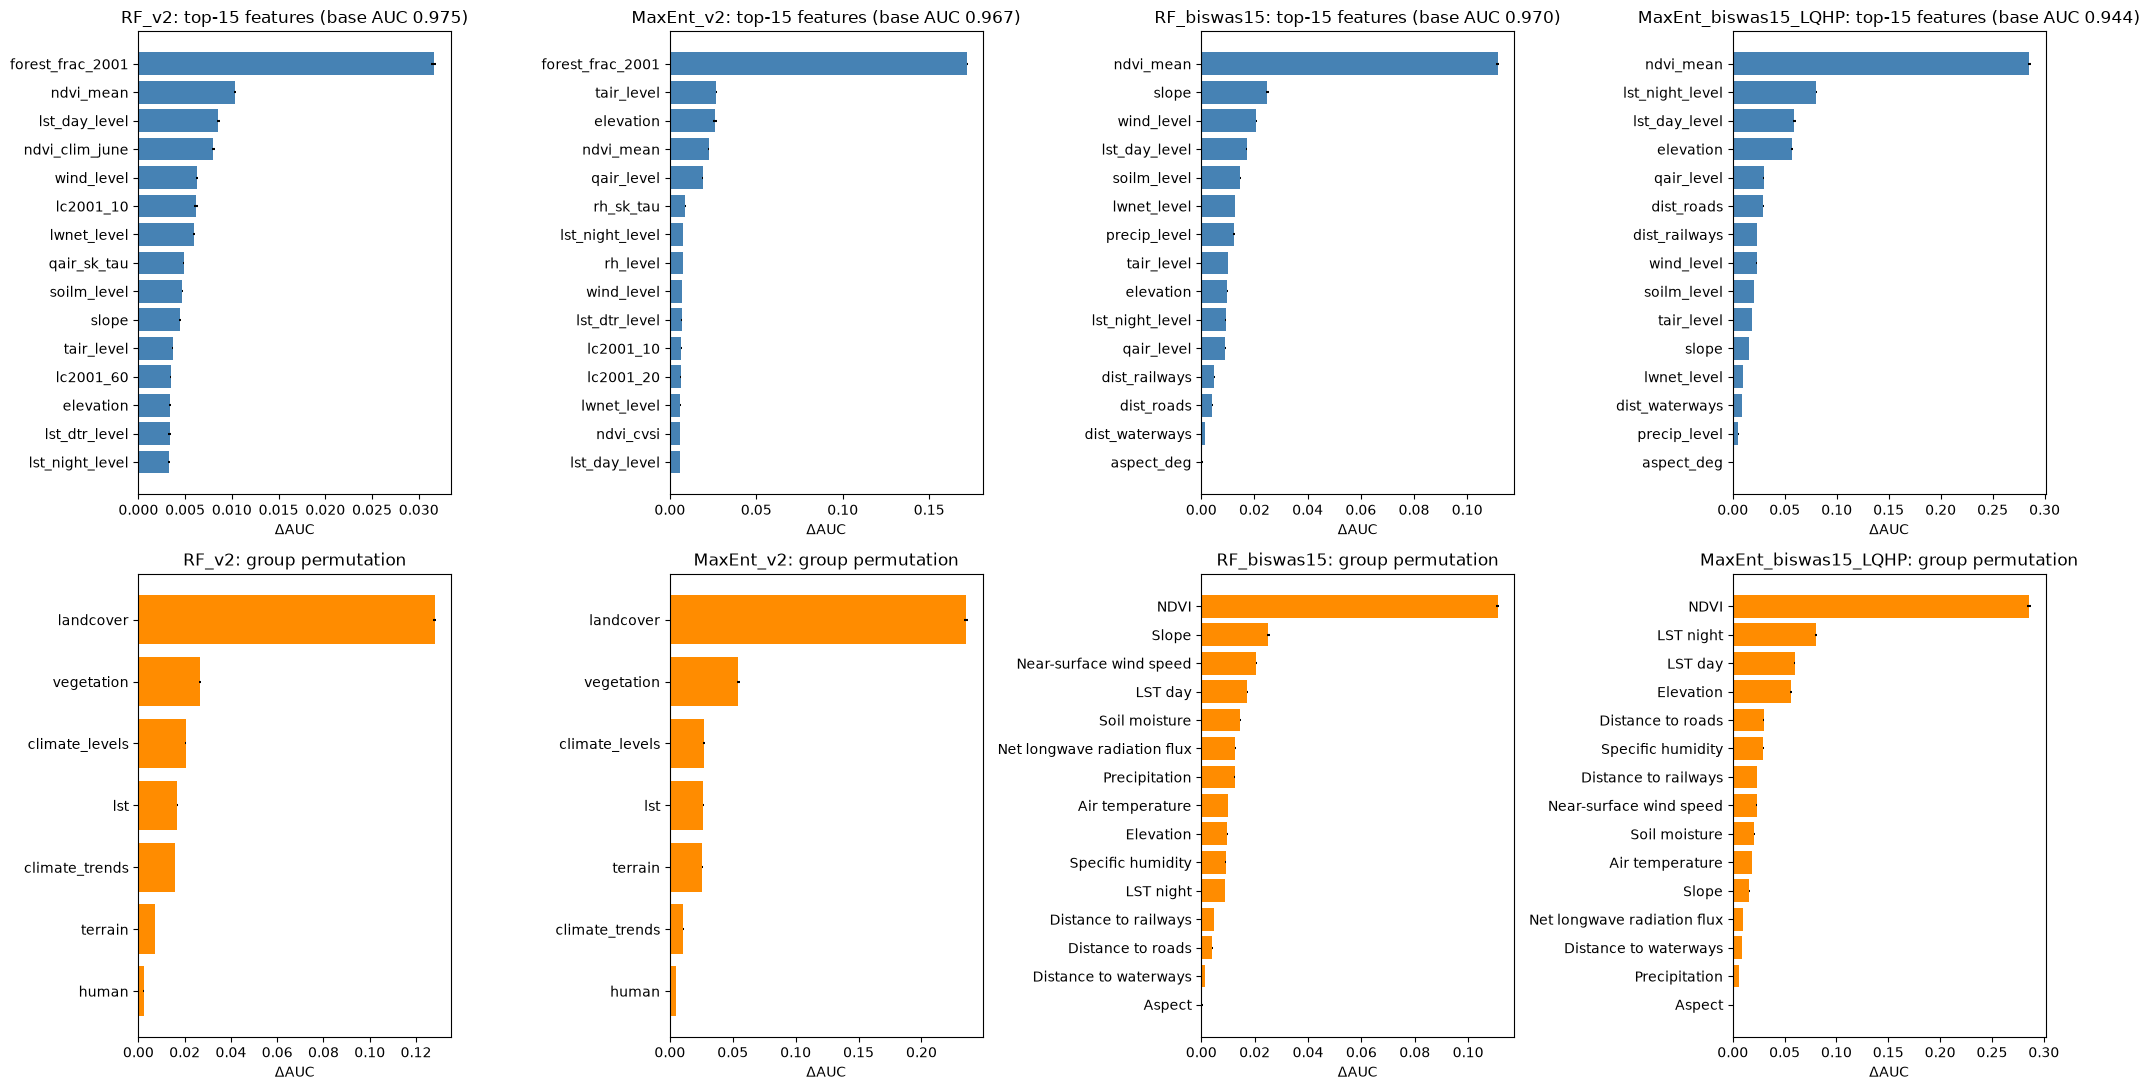

,RF_v2,MaxEnt_v2,RF_biswas15,MaxEnt_biswas15_LQHP
Air temperature,NaN,NaN,0.01002,0.01863
Aspect,NaN,NaN,0.00043,0.00014
Distance to railways,NaN,NaN,0.00477,0.02354
Distance to roads,NaN,NaN,0.00415,0.02963
Distance to waterways,NaN,NaN,0.00132,0.00913
Elevation,NaN,NaN,0.00979,0.05650
LST day,NaN,NaN,0.01718,0.05954
LST night,NaN,NaN,0.00893,0.08018
NDVI,NaN,NaN,0.11101,0.28549
Near-surface wind speed,NaN,NaN,0.02057,0.02310


In [9]:
strip = lambda c: re.sub(r"^(v2_|b15_)", "", c)
IMP = {m: json.load(open(find(f"importance__trackA__{m}.json"))) for m in IMPORTANCE_MODELS if find(f"importance__trackA__{m}.json")}
if IMP:
    fig, ax = plt.subplots(2, len(IMP), figsize=(5.2 * len(IMP), 11), squeeze=False)
    for j, (m, d) in enumerate(IMP.items()):
        f = sorted(((strip(k), v[0], v[1]) for k, v in d["feature"].items()), key=lambda t: t[1])[-15:]
        ax[0, j].barh([t[0] for t in f], [t[1] for t in f], xerr=[t[2] for t in f], color="steelblue")
        ax[0, j].set(title=f"{m}: top-15 features (base AUC {d['baseline_auc']:.3f})", xlabel="ΔAUC")
        g = sorted(d["group"].items(), key=lambda kv: kv[1][0])
        ax[1, j].barh([k for k, _ in g], [v[0] for _, v in g], xerr=[v[1] for _, v in g], color="darkorange")
        ax[1, j].set(title=f"{m}: group permutation", xlabel="ΔAUC")
    fig.tight_layout(); fig.savefig(FIG_DIR / "nb_permutation_importance.png", dpi=150); plt.show()
    show(pd.DataFrame({m: pd.Series({k: v[0] for k, v in d["group"].items()}) for m, d in IMP.items()}).round(5))
else:
    print("No importance files found.")

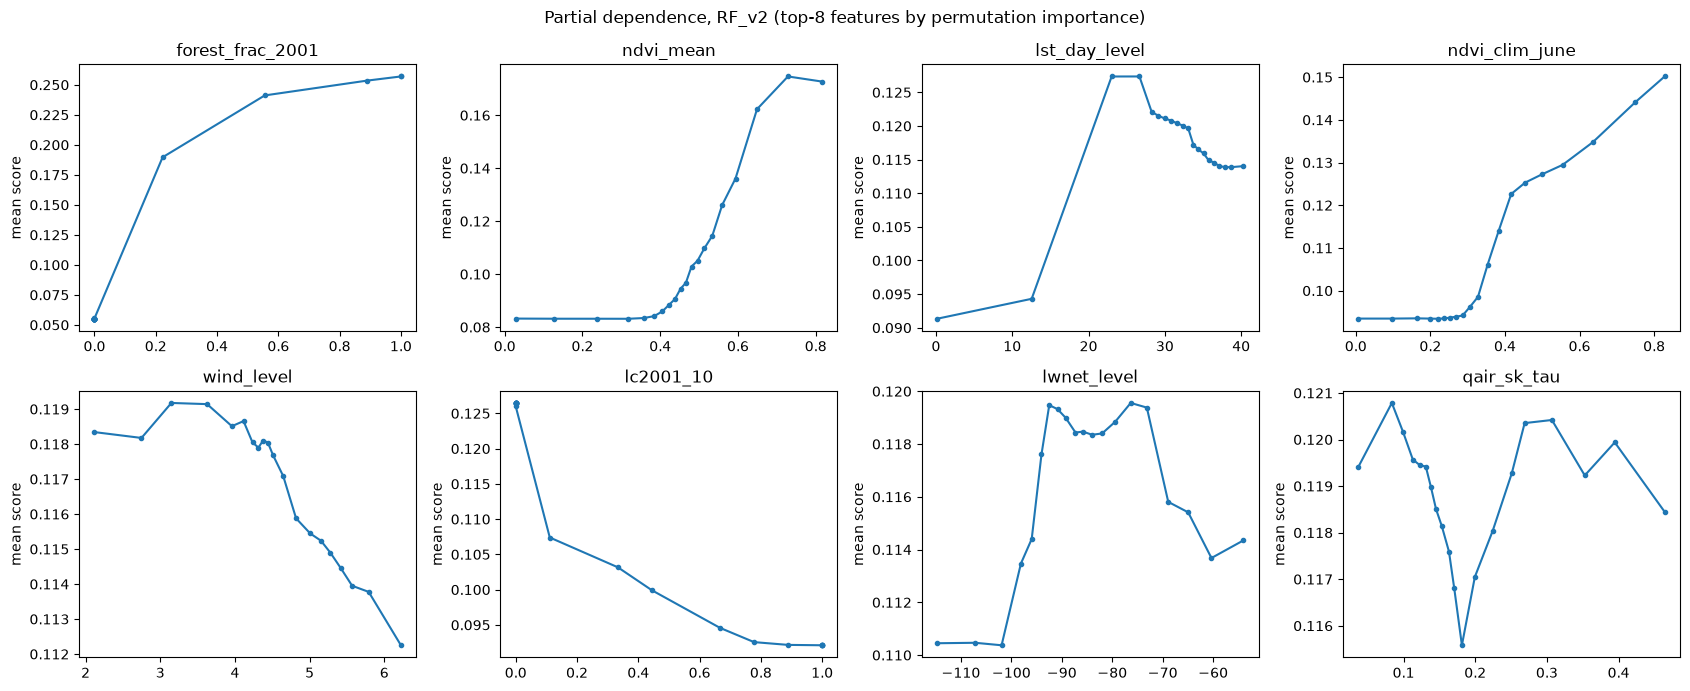

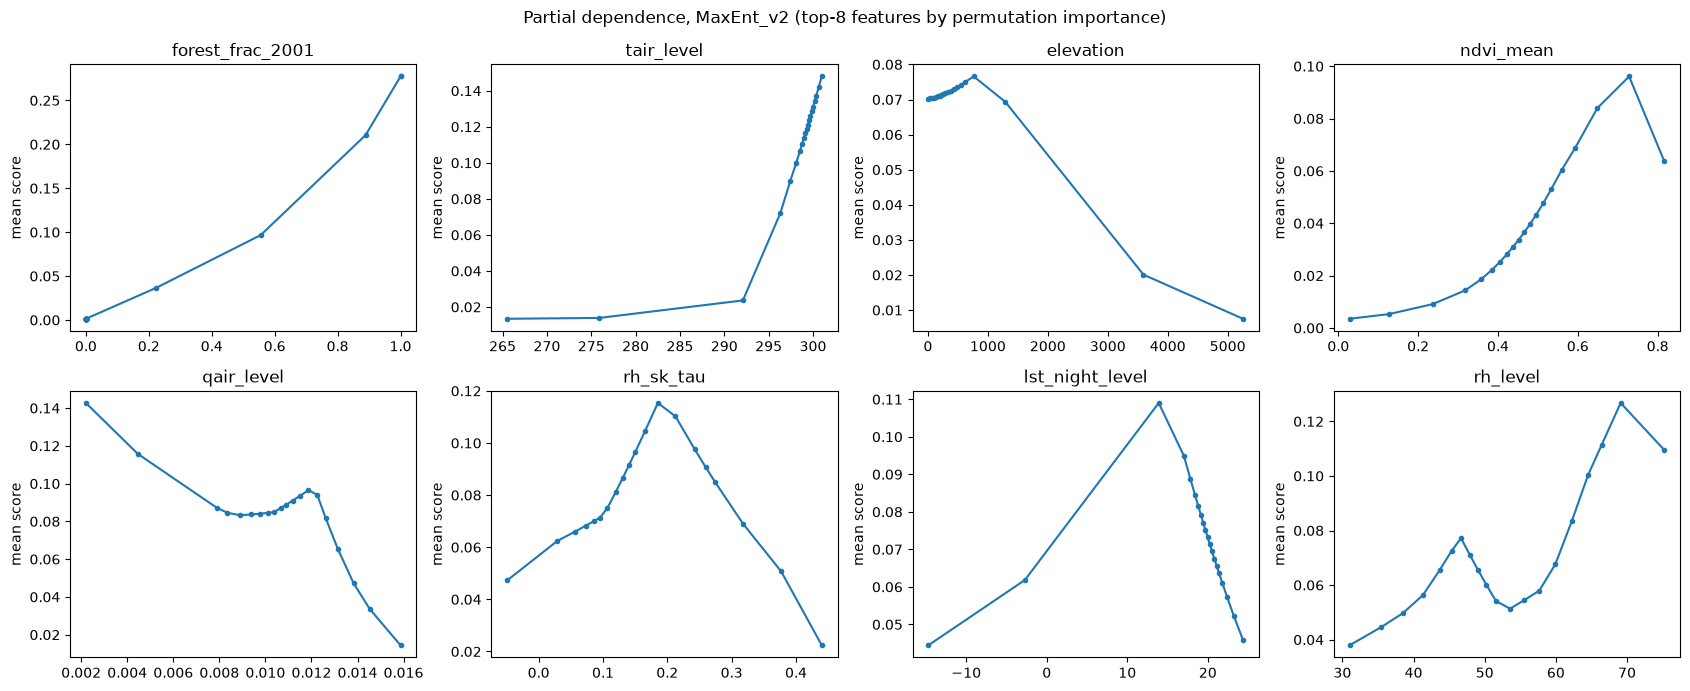

In [10]:
for m in ("RF_v2", "MaxEnt_v2"):
    if m not in IMP or "pdp" not in IMP[m]:
        continue
    d = IMP[m]; top = [k for k, _ in sorted(d["feature"].items(), key=lambda kv: -kv[1][0])[:8]]
    fig, ax = plt.subplots(2, 4, figsize=(17, 7))
    for a, c in zip(ax.ravel(), top):
        a.plot(d["pdp"][c]["grid"], d["pdp"][c]["mean_response"], "o-", ms=3); a.set(title=strip(c), ylabel="mean score")
    fig.suptitle(f"Partial dependence, {m} (top-8 features by permutation importance)"); fig.tight_layout()
    fig.savefig(FIG_DIR / f"nb_pdp_{m}.png", dpi=150); plt.show()

## Spatial generalisation: B1 (2° blocks, 3 folds) and B2 (6 regions, leave one out)

The folds and regions are identical to CDR-PINO's. Validation is carved from whole blocks of the training side.
`PAIRED_B1_B2.csv` gives pooled-fold AUC differences with a block bootstrap over 2° blocks (400k-pixel subsample, 300
resamples).

In [11]:
S = read_csv("B1_B2_SUMMARY.csv")
show(S.sort_values(["experiment", "population", "auc_mean_over_folds"], ascending=[True, False, False]) if S is not None else None)
for exp, key in (("B1", "fold"), ("B2", "region")):
    X = M[M.experiment == exp]
    if len(X):
        print(f"{exp}: per-{key} ROC-AUC")
        show(X.pivot_table(index=["tag", "population"], columns=key, values="roc_auc").round(4).reset_index())
PB = read_csv("PAIRED_B1_B2.csv")
show(PB, ["experiment", "model_A", "model_B", "population", "n_pixels", "n_blocks", "pooled_auc_A", "pooled_auc_B", "pooled_diff",
          "blockboot_ci95_lo", "blockboot_ci95_hi", "blockboot_p", "n_units_A_better"] if PB is not None else None)

,experiment,tag,population,n_folds,auc_mean_over_folds,auc_sd_over_folds,auc_min,auc_max,ap_mean_over_folds,prevalence_mean
9,B1,RF_v1_corrlabel,forest,3,0.837993,0.042205,0.803693,0.897445,0.582833,0.224306
11,B1,RF_v2,forest,3,0.837986,0.038631,0.803269,0.891876,0.582837,0.224306
3,B1,MaxEnt_v2,forest,3,0.828445,0.028969,0.805653,0.869323,0.562978,0.224306
5,B1,RF_biswas15,forest,3,0.808284,0.041802,0.768338,0.865997,0.534213,0.224306
7,B1,RF_cdr7static,forest,3,0.793178,0.025865,0.771401,0.829520,0.472826,0.224306
1,B1,MaxEnt_biswas15_LQHP,forest,3,0.787042,0.038213,0.754259,0.840640,0.495319,0.224306
8,B1,RF_v1_corrlabel,all,3,0.959683,0.014475,0.942736,0.978101,0.581921,0.064554
10,B1,RF_v2,all,3,0.959352,0.014067,0.942159,0.976617,0.581497,0.064554
2,B1,MaxEnt_v2,all,3,0.956417,0.012283,0.941232,0.971314,0.560884,0.064554
6,B1,RF_cdr7static,all,3,0.948607,0.012474,0.932686,0.963149,0.471621,0.064554


B1: per-fold ROC-AUC


fold,tag,population,0.0,1.0,2.0
0,MaxEnt_biswas15_LQHP,all,0.9353,0.9504,0.9106
1,MaxEnt_biswas15_LQHP,forest,0.7662,0.8406,0.7543
2,MaxEnt_v2,all,0.9567,0.9713,0.9412
3,MaxEnt_v2,forest,0.8104,0.8693,0.8057
4,RF_biswas15,all,0.9480,0.9658,0.9231
5,RF_biswas15,forest,0.7905,0.8660,0.7683
6,RF_cdr7static,all,0.9500,0.9631,0.9327
7,RF_cdr7static,forest,0.7786,0.8295,0.7714
8,RF_v1_corrlabel,all,0.9582,0.9781,0.9427
9,RF_v1_corrlabel,forest,0.8128,0.8974,0.8037


B2: per-region ROC-AUC


region,tag,population,0.0,1.0,2.0,3.0,4.0,5.0
0,MaxEnt_biswas15_LQHP,all,0.9194,0.9133,0.8251,0.6632,0.9082,0.9059
1,MaxEnt_biswas15_LQHP,forest,0.7984,0.7117,0.5120,0.5379,0.7543,0.7251
2,MaxEnt_v2,all,0.9740,0.9441,0.8792,0.7722,0.8861,0.9488
3,MaxEnt_v2,forest,0.7998,0.7640,0.6374,0.6584,0.7469,0.7746
4,RF_biswas15,all,0.9000,0.9264,0.8655,0.7932,0.9328,0.9186
5,RF_biswas15,forest,0.7432,0.7274,0.6279,0.7087,0.7620,0.7227
6,RF_cdr7static,all,0.9740,0.9407,0.8844,0.8375,0.9541,0.9479
7,RF_cdr7static,forest,0.8047,0.7498,0.6354,0.7410,0.7971,0.7688
8,RF_v2,all,0.9777,0.9429,0.9123,0.8674,0.9561,0.9545
9,RF_v2,forest,0.8296,0.7575,0.7243,0.7839,0.8006,0.7972


,experiment,model_A,model_B,population,n_pixels,n_blocks,pooled_auc_A,pooled_auc_B,pooled_diff,blockboot_ci95_lo,blockboot_ci95_hi,blockboot_p,n_units_A_better
0,B1,RF_v2,RF_biswas15,all,4160767,116,0.960530,0.946972,0.013558,0.010545,0.017542,0.000000,3
1,B1,RF_v2,RF_biswas15,forest,1197538,116,0.838504,0.808917,0.029586,0.022153,0.039384,0.000000,3
2,B1,RF_v2,MaxEnt_v2,all,4160767,116,0.960530,0.957223,0.003306,0.001208,0.006550,0.006667,3
3,B1,RF_v2,MaxEnt_v2,forest,1197538,116,0.838504,0.828686,0.009818,-0.001116,0.021983,0.106667,2
4,B1,RF_v2,RF_cdr7static,all,4160767,116,0.960530,0.948371,0.012159,0.007754,0.016531,0.000000,3
5,B1,RF_v2,RF_cdr7static,forest,1197538,116,0.838504,0.789137,0.049367,0.031375,0.065580,0.000000,3
6,B1,RF_biswas15,MaxEnt_biswas15_LQHP,all,4160767,116,0.946972,0.933065,0.013906,0.008135,0.021307,0.000000,3
7,B1,RF_biswas15,MaxEnt_biswas15_LQHP,forest,1197538,116,0.808917,0.789008,0.019909,0.009208,0.033610,0.000000,3
8,B1,RF_v2,RF_v1_corrlabel,all,4160767,116,0.960530,0.961069,-0.000539,-0.002142,0.000537,0.160000,1
9,B1,RF_v2,RF_v1_corrlabel,forest,1197538,116,0.838504,0.839285,-0.000781,-0.005658,0.004586,0.720000,1


## B3 (static temporal analogue) with persistence null

The same pixels are used for fitting and testing. The model learns "burned in non-test years" and is scored against
"burned in 2000/2008/2009/2015". The persistence null scores each pixel by whether it burned in any non-test year. There
is no validation split here, so no threshold metrics are reported.

In [12]:
show(M[M.experiment == "B3static"].sort_values(["population", "roc_auc"], ascending=[False, False]),
     ["tag", "population", "n", "prevalence", "roc_auc", "auc_ci", "ap", "ap_ci", "brier", "ece", "fit_sec"])

,tag,population,n,prevalence,roc_auc,auc_ci,ap,ap_ci,brier,ece,fit_sec
265,RF_v2,forest,1197538,0.058487,0.872185,"[0.8714, 0.8730]",0.282303,"[0.2799, 0.2847]",0.280470,0.373982,195.142326
267,RF_biswas15,forest,1197538,0.058487,0.864458,"[0.8635, 0.8654]",0.266198,"[0.2639, 0.2685]",0.277475,0.369772,127.990182
269,MaxEnt_v2,forest,1197538,0.058487,0.846822,"[0.8457, 0.8480]",0.252636,"[0.2510, 0.2555]",0.145501,0.207247,914.902123
263,persistence_null_everburned_trainyears,forest,1197538,0.058487,0.743509,"[0.7418, 0.7447]",0.145740,"[0.1448, 0.1465]",0.184524,0.184523,NaN
264,RF_v2,all,4160768,0.016858,0.964630,"[0.9644, 0.9649]",0.282201,"[0.2800, 0.2856]",0.080948,0.108807,195.142326
266,RF_biswas15,all,4160768,0.016858,0.961469,"[0.9612, 0.9618]",0.264989,"[0.2629, 0.2678]",0.081701,0.113718,127.990182
268,MaxEnt_v2,all,4160768,0.016858,0.957470,"[0.9572, 0.9579]",0.252353,"[0.2506, 0.2558]",0.041920,0.059989,914.902123
262,persistence_null_everburned_trainyears,all,4160768,0.016858,0.806778,"[0.8053, 0.8087]",0.131329,"[0.1302, 0.1327]",0.053349,0.053349,NaN


## MaxEnt training-sample-size sensitivity

These runs test whether the RF–MaxEnt gap is an artefact of the 150k subsample. The fit time grows roughly as
n^1.6.

ap_mean         auc_mean          auc_sd         fit_sec_mean            n_seeds       
population     all  forest      all  forest     all  forest          all     forest     all forest
rows                                                                                              
50000       0.6349  0.6369   0.9640  0.8546  0.0005  0.0021     153.6763   153.6763     3.0    3.0
100000      0.6541  0.6558   0.9663  0.8629  0.0003  0.0012     507.4095   507.4095     3.0    3.0
150000      0.6634  0.6651   0.9673  0.8667  0.0002  0.0008    1134.9278  1134.9278     3.0    3.0
300000      0.6709  0.6725   0.9680  0.8697     NaN     NaN    3411.1269  3411.1269     1.0    1.0
500000      0.6756  0.6773   0.9685  0.8717     NaN     NaN    7302.9291  7302.9291     1.0    1.0

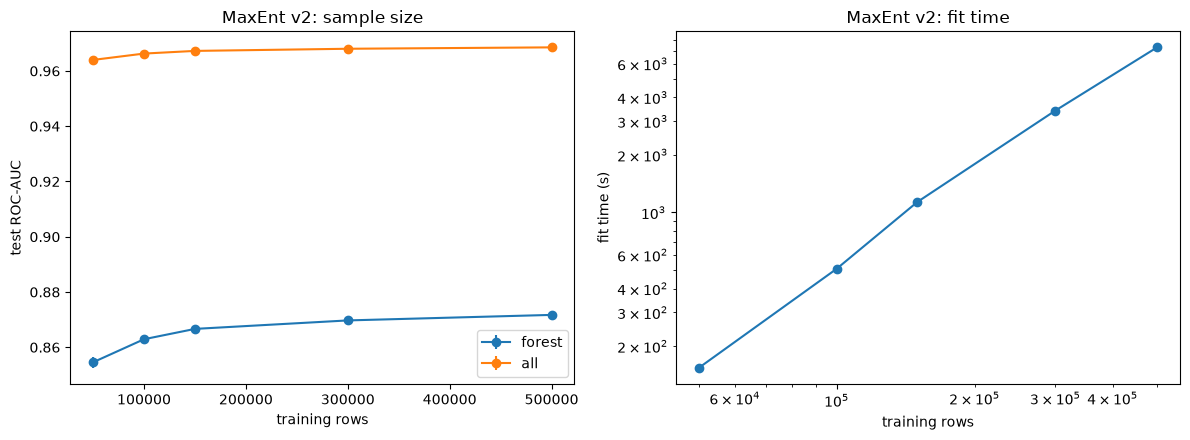

In [13]:
MX = M[M.experiment == "maxent_n"].copy()
if len(MX):
    MX["rows"] = MX.tag.str.extract(r"_n(\d+)_")[0].astype(int); MX["seed"] = MX.tag.str.extract(r"seed(\d+)")[0].astype(int)
    tab = MX.groupby(["rows", "population"]).agg(n_seeds=("seed", "nunique"), auc_mean=("roc_auc", "mean"), auc_sd=("roc_auc", "std"),
                                                ap_mean=("ap", "mean"), fit_sec_mean=("fit_sec", "mean")).reset_index()
    show(tab.pivot_table(index="rows", columns="population", values=["auc_mean", "auc_sd", "ap_mean", "fit_sec_mean", "n_seeds"]).round(4))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for pop in ("forest", "all"):
        s = tab[tab.population == pop]; ax[0].errorbar(s.rows, s.auc_mean, yerr=s.auc_sd.fillna(0), marker="o", label=pop)
    s = tab[tab.population == "all"]; ax[1].loglog(s.rows, s.fit_sec_mean, "o-")
    ax[0].set(xlabel="training rows", ylabel="test ROC-AUC", title="MaxEnt v2: sample size"); ax[0].legend()
    ax[1].set(xlabel="training rows", ylabel="fit time (s)", title="MaxEnt v2: fit time")
    fig.tight_layout(); fig.savefig(FIG_DIR / "nb_maxent_sample_size.png", dpi=150); plt.show()
else:
    print("No maxent_n rows.")

## Bridge: classical models on CDR-PINO's own 12 km cells

The bridge uses CDR-PINO's own cells, covariates (`cdr7`) and partitions, and also the 55 v2 features averaged into
12 km cells (`v2agg`). This separates the model and physics effects from the predictor-set and population effects. The
B3 rows are monthly (t → t+1), including climatological and seasonal null models. Prediction files
`bridge12_{track}__{tag}.npz` are paired against CDR-PINO in the CDR analysis.

In [14]:
BR = M[M.experiment.str.startswith("bridge12")].copy()
if len(BR):
    BR["model_features"] = BR.tag.str.replace(r"_[fr]\d+$", "", regex=True)
    tb = BR.groupby(["experiment", "model_features", "population"]).agg(n_units=("roc_auc", "size"), auc_mean=("roc_auc", "mean"),
                                                                      auc_sd=("roc_auc", "std"), ap_mean=("ap", "mean"),
                                                                      prevalence=("prevalence", "mean")).reset_index()
    show(tb.sort_values(["experiment", "population", "auc_mean"], ascending=[True, False, False]).round(4))
else:
    print("No bridge12 rows.")

,experiment,model_features,population,n_units,auc_mean,auc_sd,ap_mean,prevalence
11,bridge12_A,RF_v2agg,forest,1,0.9549,NaN,0.9764,0.6523
9,bridge12_A,RF_cdr7,forest,1,0.9502,NaN,0.9728,0.6523
7,bridge12_A,MaxEnt_v2agg,forest,1,0.9385,NaN,0.9608,0.6523
5,bridge12_A,MaxEnt_cdr7,forest,1,0.9270,NaN,0.9603,0.6523
3,bridge12_A,LogReg_v2agg,forest,1,0.9190,NaN,0.9552,0.6523
1,bridge12_A,LogReg_cdr7,forest,1,0.8740,NaN,0.8978,0.6523
10,bridge12_A,RF_v2agg,all,1,0.9808,NaN,0.9754,0.4206
8,bridge12_A,RF_cdr7,all,1,0.9800,NaN,0.9724,0.4206
6,bridge12_A,MaxEnt_v2agg,all,1,0.9662,NaN,0.9539,0.4206
4,bridge12_A,MaxEnt_cdr7,all,1,0.9585,NaN,0.9516,0.4206


## Biswas-style baseline: reimplementation, NOT the original Biswas et al. (2025) result

This uses 0.25° cells, 15 level predictors, 2020 forest-fire presence cells, background cells, and MaxEnt L+Q+H+P with
β = 1, over 10 random 75/25 presence splits. The AUC is **presence-vs-background at 0.25°**, so it is not comparable with
the pixel-level AUCs above. Percent contribution is not computed, because elapid does not produce this optimiser
quantity.

In [15]:
p = find("BISWAS_STYLE_BASELINE.json")
if p is not None:
    B = json.load(open(p))
    print("LABEL:", B.get("label"))
    rs, rv = B["replica_2020_presences_025deg"]["summary"], B["biswas_reported"]
    print(f"Reimplementation test AUC {rs['test_auc_mean']:.3f} ± {rs['test_auc_sd']:.3f} (train {rs['train_auc_mean']:.3f}); "
          f"Biswas et al. REPORTED test {rv['test_auc']} / train {rv['train_auc']} (reported, not recomputed)")
    print("Grid:", B["grid"])
    run0 = B["replica_2020_presences_025deg"]["runs"][0]
    tab = pd.DataFrame({"reimpl_perm_importance_pct": run0.get("permutation_importance_pct", {}),
                        "biswas_reported_perm_importance_pct": rv["permutation_importance_pct"],
                        "jackknife_only_test_auc": {k: v["only_test_auc"] for k, v in run0.get("jackknife", {}).items()},
                        "jackknife_without_test_auc": {k: v["without_test_auc"] for k, v in run0.get("jackknife", {}).items()},
                        "fig11_corr_reimpl": B["fig11_correlations_025deg"],
                        "fig11_corr_biswas_reported": B["fig11_biswas_reported"]})
    show(tab.sort_values("reimpl_perm_importance_pct", ascending=False).round(3).reset_index().rename(columns={"index": "variable"}))
    v = B.get("variant_2001_2020_presences_025deg", {}).get("summary")
    if v: print(f"Variant (2001-2020 presences, 3 splits): test AUC {v['test_auc_mean']:.3f} ± {v['test_auc_sd']:.3f}")
else:
    print("BISWAS_STYLE_BASELINE.json not found.")

LABEL: BISWAS-STYLE REIMPLEMENTATION (not the original Biswas et al. result)
Reimplementation test AUC 0.893 ± 0.009 (train 0.902); Biswas et al. REPORTED test 0.879 / train 0.894 (reported, not recomputed)
Grid: {'n_cells_valid': 4630, 'n_presence_cells_2020': 1292, 'n_presence_cells_2001_2020': 2544, 'biswas_presence_total': 2439, 'n_2020_forest_fire_points': 16421, 'ten_percent_of_2020_points': 1642}


,variable,reimpl_perm_importance_pct,biswas_reported_perm_importance_pct,jackknife_only_test_auc,jackknife_without_test_auc,fig11_corr_reimpl,fig11_corr_biswas_reported
0,NDVI,18.983,22.3,0.799,0.888,0.456,0.43
1,LST night,14.280,10.1,0.572,0.891,0.044,NaN
2,Air temperature,13.158,13.1,0.734,0.890,0.011,NaN
3,Elevation,10.715,2.4,0.697,0.894,-0.029,NaN
4,LST day,8.135,9.6,0.713,0.889,-0.118,NaN
5,Soil moisture,7.476,3.8,0.758,0.891,0.389,0.27
6,Slope,5.806,5.6,0.794,0.889,0.223,0.40
7,Net longwave radiation flux,5.418,1.8,0.726,0.883,0.361,0.28
8,Specific humidity,3.097,13.0,0.723,0.890,0.166,NaN
9,Distance to waterways,2.852,0.5,0.566,0.892,-0.074,NaN


Variant (2001-2020 presences, 3 splits): test AUC 0.948 ± 0.006


## Final map: RF v2 relative susceptibility score

The model is refit on the v2 training partition with the same seed as Track A, so the refit reproduces Track A's test
scores bit-exactly (checked in `step7_models.py map`). The values are **class-balanced RF scores, not calibrated
probabilities**. The 5 classes use quantile breaks (20/40/60/80%) over **forest** pixels, stated in the GeoTIFF tags.

Susceptibility_RF_v2_score.tif
   AUDIT: results/final (2026-09-24/25 audit)
   CREATED: 2026-09-25T11:40:53
   CRS: EPSG:4326, 1/120 deg
   LABEL: MODIS C6.1 forest-fire occurrence 2000-11-01..2022-12-15, containing-pixel rasterisation
   MODEL: RandomForest v2 (55 features), {"n_estimators": 200, "max_depth": 25, "min_samples_leaf": 3, "class_weight": "balanced", "max_features": "sqrt", "random_state": 42}
   PERIOD: 2000-11-01 to 2022-12-15 (static, whole-period susceptibility)
   ROOT_COMMIT: fb0d8aa
   VALUES: class-balanced RF score in [0,1]; RELATIVE susceptibility, NOT a calibrated probability
   AREA_OR_POINT: Area


C:\Users\Admin\AppData\Local\Temp\ipykernel_2664\945626399.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1, out_shape=(src.height // 4, src.width // 4), resampling=Resampling.nearest)


Susceptibility_RF_v2_5class_quantile.tif
   AUDIT: results/final (2026-09-24/25 audit)
   CLASSES: 1=Very low..5=Very high; quantile breaks (20/40/60/80%) of the score over FOREST pixels (forest_frac_2001>0), applied to all pixels: 0.0431, 0.2099, 0.5820, 0.8929
   CREATED: 2026-09-25T11:40:53
   CRS: EPSG:4326, 1/120 deg
   LABEL: MODIS C6.1 forest-fire occurrence 2000-11-01..2022-12-15, containing-pixel rasterisation
   MODEL: RandomForest v2 (55 features), {"n_estimators": 200, "max_depth": 25, "min_samples_leaf": 3, "class_weight": "balanced", "max_features": "sqrt", "random_state": 42}
   PERIOD: 2000-11-01 to 2022-12-15 (static, whole-period susceptibility)
   ROOT_COMMIT: fb0d8aa
   VALUES: class-balanced RF score in [0,1]; RELATIVE susceptibility, NOT a calibrated probability
   AREA_OR_POINT: Area


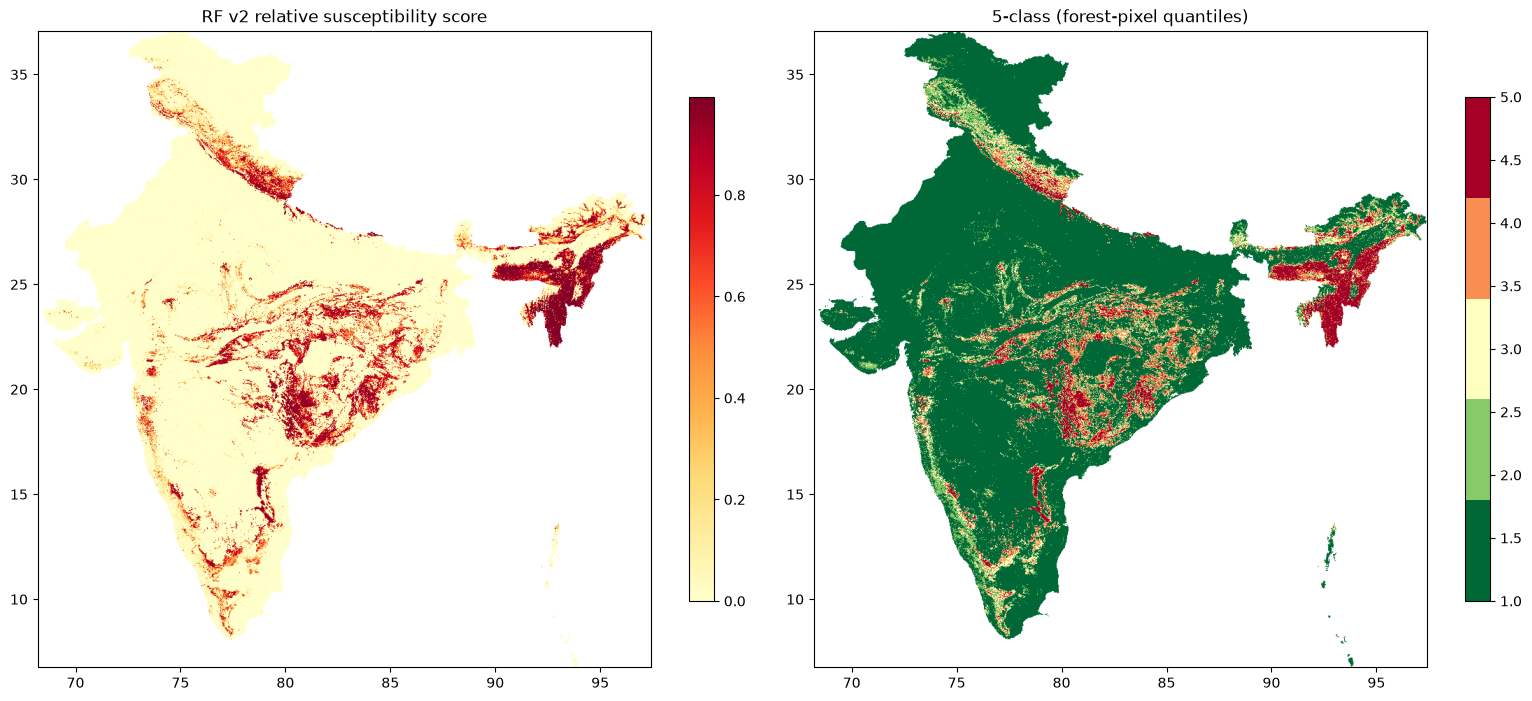

In [16]:
import rasterio
from rasterio.enums import Resampling
fs, fc = find("Susceptibility_RF_v2_score.tif"), find("Susceptibility_RF_v2_5class_quantile.tif")
if fs is not None:
    fig, ax = plt.subplots(1, 2 if fc is not None else 1, figsize=(16, 7.5), squeeze=False)
    for a, f, cmap, title in ((ax[0, 0], fs, "YlOrRd", "RF v2 relative susceptibility score"),) + (((ax[0, 1], fc, plt.get_cmap("RdYlGn_r", 5), "5-class (forest-pixel quantiles)"),) if fc is not None else ()):
        with rasterio.open(f) as src:
            arr = src.read(1, out_shape=(src.height // 4, src.width // 4), resampling=Resampling.nearest)
            b = src.bounds; tags = src.tags()
        im = a.imshow(arr, cmap=cmap, extent=(b.left, b.right, b.bottom, b.top)); a.set_title(title); plt.colorbar(im, ax=a, shrink=.7)
        print(f.name); [print(f"   {k}: {v}") for k, v in tags.items()]
    fig.tight_layout(); fig.savefig(FIG_DIR / "nb_final_map.png", dpi=130); plt.show()
    rep = find("Susceptibility_RF_v2_map_report.json")
    if rep is not None: print(json.dumps({k: v for k, v in json.load(open(rep)).items() if k != "provenance"}, indent=1))
else:
    print("Final map GeoTIFFs not found.")

## Per-track summary

This table shows the classical 1 km and 12 km rows of the audit's `FINAL_METRICS.csv`, or, after a refit, of
`STEP7_METRICS_BY_TRACK.csv`. For CDR-PINO rows and paper numbers, use `results/FINAL_MANUSCRIPT_NUMBERS.md`.

In [17]:
FM = read_csv("FINAL_METRICS.csv")
src = "FINAL_METRICS.csv"
if FM is None:
    FM, src = read_csv("STEP7_METRICS_BY_TRACK.csv"), "STEP7_METRICS_BY_TRACK.csv"
if FM is not None:
    FM = FM[~FM.track.astype(str).str.startswith("CDR_")]
    key = FM[FM.model.isin(PRIMARY + ["persistence_null_everburned_trainyears"]) & FM.track.isin(["trackA", "B1", "B2", "B3static"])]
    print("Source:", src)
    show(key.sort_values(["track", "population", "roc_auc"], ascending=[True, False, False]),
         ["track", "model", "population", "n_units", "prevalence", "roc_auc", "roc_auc_sd_units", "ap", "brier", "ece", "precision",
          "recall_sensitivity", "specificity", "f1", "threshold_rule"])

Source: FINAL_METRICS.csv


,track,model,population,n_units,prevalence,roc_auc,roc_auc_sd_units,ap,brier,ece,precision,recall_sensitivity,specificity,f1,threshold_rule
11,B1,RF_v2,forest,3,0.224306,0.837986,0.038631,0.582837,0.160464,0.166576,0.490048,0.733171,0.766333,0.578604,max-F1 on validation
3,B1,MaxEnt_v2,forest,3,0.224306,0.828445,0.028969,0.562978,0.141955,0.067904,0.512874,0.645250,0.822728,0.569196,max-F1 on validation
5,B1,RF_biswas15,forest,3,0.224306,0.808284,0.041802,0.534213,0.163532,0.144212,0.432122,0.796580,0.689250,0.557527,max-F1 on validation
7,B1,RF_cdr7static,forest,3,0.224306,0.793178,0.025865,0.472826,0.241027,0.266198,0.430874,0.720444,0.723587,0.538797,max-F1 on validation
1,B1,MaxEnt_biswas15_LQHP,forest,3,0.224306,0.787042,0.038213,0.495319,0.169470,0.114148,0.411463,0.763196,0.677687,0.532794,max-F1 on validation
10,B1,RF_v2,all,3,0.064554,0.959352,0.014067,0.581497,0.047236,0.053413,0.490072,0.730325,0.940950,0.577710,max-F1 on validation
2,B1,MaxEnt_v2,all,3,0.064554,0.956417,0.012283,0.560884,0.041359,0.019316,0.512499,0.642712,0.956721,0.567952,max-F1 on validation
6,B1,RF_cdr7static,all,3,0.064554,0.948607,0.012474,0.471621,0.070876,0.079462,0.430846,0.717592,0.933530,0.537971,max-F1 on validation
4,B1,RF_biswas15,all,3,0.064554,0.945621,0.017481,0.522943,0.050691,0.062614,0.427747,0.787503,0.921471,0.550613,max-F1 on validation
0,B1,MaxEnt_biswas15_LQHP,all,3,0.064554,0.932120,0.016395,0.475547,0.051616,0.041478,0.415498,0.719107,0.927208,0.525246,max-F1 on validation


## Computational cost (measured)

These are wall-clock fit times recorded in the registry by each run. The carried-forward timings for Steps 1–6 that
the v1 notebook hard-coded have been removed, because they were never remeasured.

In [18]:
C = M[(M.population == "all") & M.fit_sec.notna()]
if len(C):
    cost = C.groupby(["experiment", "model"]).agg(n_fits=("fit_sec", "size"), fit_sec_total=("fit_sec", "sum"),
                                                  fit_sec_median=("fit_sec", "median"), train_rows_median=("train_rows", "median")).reset_index()
    show(cost.sort_values("fit_sec_total", ascending=False).round(1))
    print(f"Total recorded fit time: {C.fit_sec.sum() / 3600:.1f} h (excludes prediction, importance, bridge B3 monthly RF and Biswas-style runs)")

,experiment,model,n_fits,fit_sec_total,fit_sec_median,train_rows_median
11,maxent_n,MaxEnt(elapid),11,16102.1,517.9,100000.0
7,B2,MX_HIST,6,7547.5,1377.0,150000.0
6,B2,MX_BISWAS,6,3667.7,615.7,150000.0
15,trackA,MX_HIST,2,3556.6,1778.3,150000.0
1,B1,MX_HIST,3,3528.5,1134.3,150000.0
3,B1hist,MX_HIST,3,3295.0,1065.6,NaN
16,trackA,RF,15,2158.9,151.4,2704498.0
8,B2,RF,18,1957.3,96.3,2771192.5
12,repro,MaxEnt(elapid),1,1894.5,1894.5,150000.0
0,B1,MX_BISWAS,3,1567.3,562.9,150000.0


Total recorded fit time: 13.9 h (excludes prediction, importance, bridge B3 monthly RF and Biswas-style runs)


## Summary

- **Primary population: forest pixels.** Report the all-pixel AUCs only next to the forest AUCs and their prevalences.
  Over all pixels, forest fraction alone reaches AUC ≈ 0.91.
- The classical models are the baseline for CDR-PINO. The bridge tables compare them on CDR-PINO's own cells,
  covariates and partitions.
- The RF scores and the map are **relative** susceptibility, not calibrated probabilities (see the ECE values).
- The Biswas-style numbers come from a **reimplementation**, and its presence-vs-background AUC is not comparable with
  pixel-level AUCs.
- Reference: `results/FULL_METHODOLOGY_AUDIT.md`. Numbers for the paper: `results/FINAL_MANUSCRIPT_NUMBERS.md`.

Code: `step7_models.py` (experiments, CLI), `preprocessing.py` (split and imputation), `step7_eval.py` (metrics,
bootstrap, DeLong, block bootstrap; a verbatim port of the audit's `eval_utils.py`).